In [1]:
!pip install torchtt
import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch as tn
import torchtt as tntt
from torchtt._torchtt import *
from torchtt._fast_mult import *

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
  Created wheel for torchtt: filename=torchtt-0.3-cp312-cp312-linux_x86_64.whl size=3800144 sha256=b4f4113c78f121d9978d6c1e67e4fc28d428817e1a715ceb65294985db825da2
  Stored in directory: /root/.cache/pip/wheels/8f/ff/f5/987628322472e51ec9d36e3c2f6fcbb63869daaf5fcd1d81ef
Successfully built torchtt


In [2]:
a=0                  # the beginning of the interval
b=1                  # The end of the interval
c=6                  # Number of cores in the QTT
Re=1000             # The Reynolds Number
dt=0.001             # Time Marching Increment
dx = (b-a)/(2**c)    # The grid size
dx2=dx**2
n=2**c               # The dimension of the differential matrix operator'
#u_L=0.95             # left BC
#u_R=0.05             # right BC

We encode our ICs into the discretized interval,
as the interval with the number of components
equal to 2 to the power of the number of cores, models our tensor in the flattened form.


In [3]:
u = np.zeros(2**c)
for i in range(int((2**c)/2)+1):
  u[i]=1
print(u)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


We try to break the flattened array into the appropriate
form, required for the TT manipulations. Here, we are
aware that the physical legs can only get binary values
, therefore we attempt to design the array in the form of
(2,2,2,...) until the number of components exhaust.

In [4]:
u_r = np.reshape(u,(2,)*c)
#print(u_r)

With the previous stage, we can generate our tensor train
via the functionalities of the TorchTT library.

In [5]:
u_tt = tntt.TT(u_r)
#print(TT.numpy(u_tt))
print('TT cores', u_tt.cores)
print('Mode size ', u_tt.N)
print('TT rank ', u_tt.R)

TT cores [tensor([[[ 0.9995, -0.0322],
         [ 0.0322,  0.9995]]], dtype=torch.float64), tensor([[[ 7.0747e-01,  3.3307e-05],
         [ 7.0601e-01, -3.2141e-02]],

        [[ 2.2704e-02,  9.9948e-01],
         [-2.2751e-02,  1.0357e-03]]], dtype=torch.float64), tensor([[[ 7.0784e-01,  9.3481e-05],
         [ 7.0492e-01, -4.5291e-02]],

        [[ 3.1960e-02,  9.9897e-01],
         [-3.2092e-02,  2.0619e-03]]], dtype=torch.float64), tensor([[[-7.0856e-01,  2.6039e-04],
         [-7.0278e-01, -6.3596e-02]],

        [[-4.4785e-02,  9.9797e-01],
         [ 4.5153e-02,  4.0860e-03]]], dtype=torch.float64), tensor([[[-7.0997e-01,  7.1468e-04],
         [-6.9862e-01, -8.8692e-02]],

        [[ 6.2209e-02, -9.9603e-01],
         [-6.3220e-02, -8.0259e-03]]], dtype=torch.float64), tensor([[[ 4.0941],
         [ 3.9682]],

        [[-0.4883],
         [ 0.5038]]], dtype=torch.float64)]
Mode size  [2, 2, 2, 2, 2, 2]
TT rank  [1, 2, np.int64(2), np.int64(2), np.int64(2), 2, 1]


Now is the time for the essential TT operation in dealing
with differential equations i.e., the differential TT-matrix
or MPO, which will be pursued through the Finite Difference
method of dealing with matrix operators, since our multi-dimensional
MPO object can be represented via a 2^c x 2^c matrix in flattened form.
The onstruction of the MPO is relatively easy once it has been done
for low-dimensional cases. We use the centered definition of a partial derivative and point by point in the grid, df(x)/dx=f(x_n+2)-f(x_n)/2 delta_x
is held. The matrix takes form naturally form then on.

In [6]:
def create_tridiagonal_dx_mop(n, main_diag_elements, upper_diag_elements, lower_diag_elements):
    """

    Args:
        n (int): The dimension of the square matrix (n x n).
        main_diag_elements (list or ndarray): Elements for the main diagonal.
        upper_diag_elements (list or ndarray): Elements for the upper off-diagonal.
        lower_diag_elements (list or ndarray): Elements for the lower off-diagonal.

    Returns:
        numpy.ndarray: The D1 tridiagonal matrix.
    """
    matrix = np.zeros((2**c, 2**c), dtype=float)

    # Place elements on the main diagonal (k=0)
    np.fill_diagonal(matrix, main_diag_elements)

    # Place elements on the upper off-diagonal (k=1)
    # The slice matrix[:-1, 1:] ensures correct placement for upper diagonal
    np.fill_diagonal(matrix[:-1, 1:], upper_diag_elements)

    # Place elements on the lower off-diagonal (k=-1)
    # The slice matrix[1:, :-1] ensures correct placement for lower diagonal
    np.fill_diagonal(matrix[1:, :-1], lower_diag_elements)

    return matrix

In [7]:
main_diag = np.zeros(n)
upper_diag = (1/(2*dx))*np.ones(n-1)
lower_diag = (-1/(2*dx))*np.ones(n-1)

tridiagl_dx_mop = create_tridiagonal_dx_mop(n, main_diag, upper_diag, lower_diag)
print(tridiagl_dx_mop)

[[  0.  32.   0. ...   0.   0.   0.]
 [-32.   0.  32. ...   0.   0.   0.]
 [  0. -32.   0. ...   0.   0.   0.]
 ...
 [  0.   0.   0. ...   0.  32.   0.]
 [  0.   0.   0. ... -32.   0.  32.]
 [  0.   0.   0. ...   0. -32.   0.]]


We go forward by flattening the MPO and feeding it into
the powerful hands of PyTorch, which TorchTT heavily relies on
then we repeat the action of isolating the array in the form
of (2,2,2,2,...)

In [8]:
dx_op_flat = tridiagl_dx_mop.flatten()
#print(dx_op_flat)
dx_flat_tn=tn.from_numpy(dx_op_flat)
#print(dx_flat_tn)
dx_op_split = tn.reshape(dx_flat_tn,[2]*(2*c))
#print(dx_op_split)

'(These examples are appliacble to 8, 6, and 4 number of cores respectively)'

#dx_ttm = tntt.TT(dx_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2),(2,2),(2,2),(2,2),(2,2)])
dx_ttm = tntt.TT(dx_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2),(2,2),(2,2)])
#dx_ttm = tntt.TT(dx_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2)])

print(dx_ttm)

TT-matrix with sizes and ranks:
M = [2, 2, 2, 2, 2, 2]
N = [2, 2, 2, 2, 2, 2]
R = [1, np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), 1]
Device: cpu, dtype: torch.float64
#entries 152 compression 0.037109375



In the following, three different ways of applying an MPO on an MPS
is demonstrated. We go forward with the one, which demands fewer ranks
(bond dimensions in between the tensor cores. Having more of them is )
computationally inefficient (having said that, they will lead to higher accuracies)
In most of our experiments, the typical methods gave quicker feedback w.r.t. others
, which was somewhat unexpected...


In [9]:
tme = datetime.datetime.now()
du = (dx_ttm @ u_tt).round(1e-12)
tme = datetime.datetime.now() - tme
print('Time classic ', tme)
du
#print(du)
#print(TT.numpy(du))

Time classic  0:00:00.018163


TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625

In [10]:
tme = datetime.datetime.now()
du_1 = dx_ttm.fast_matvec(u_tt)
tme = datetime.datetime.now() - tme
print('Time DMRG    ', tme)
print(du_1)

Time DMRG     0:00:00.024794
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 6, 6, 6, 1]

Device: cpu, dtype: torch.float64
#entries 224 compression 3.5



In [11]:
tme = datetime.datetime.now()
du_2 = tntt.fast_mv(dx_ttm, u_tt)
tme = datetime.datetime.now() - tme
print('another method  ', tme)
print(du_2)

another method   0:00:00.010265
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 3, 3, 3, 3, 2, 1]

Device: cpu, dtype: torch.float64
#entries 76 compression 1.1875



The method was covered. The only change is the coefficients, which
are effected according to the definition of the second-order partial derivative Matrix operator

In [12]:
def create_tridiagonal_dx2_mop(n, main_diag_elements, upper_diag_elements, lower_diag_elements):
    """

    Args:
        n (int): The dimension of the square matrix (n x n).
        main_diag_elements (list or ndarray): Elements for the main diagonal.
        upper_diag_elements (list or ndarray): Elements for the upper off-diagonal.
        lower_diag_elements (list or ndarray): Elements for the lower off-diagonal.

    Returns:
        numpy.ndarray: The D2 tridiagonal matrix.
    """
    matrix = np.zeros((2**c, 2**c), dtype=float)

    # Place elements on the main diagonal (k=0)
    np.fill_diagonal(matrix, main_diag_elements)

    # Place elements on the upper off-diagonal (k=1)
    # The slice matrix[:-1, 1:] ensures correct placement for upper diagonal
    np.fill_diagonal(matrix[:-1, 1:], upper_diag_elements)

    # Place elements on the lower off-diagonal (k=-1)
    # The slice matrix[1:, :-1] ensures correct placement for lower diagonal
    np.fill_diagonal(matrix[1:, :-1], lower_diag_elements)

    return matrix

In [13]:
main_diag = (-2/dx2)*np.ones(n)
upper_diag = (1/dx2)*np.ones(n-1)
lower_diag = (1/dx2)*np.ones(n-1)

tridiagonal_dx2_mop = create_tridiagonal_dx2_mop(n, main_diag, upper_diag, lower_diag)
print(tridiagonal_dx2_mop)

[[-8192.  4096.     0. ...     0.     0.     0.]
 [ 4096. -8192.  4096. ...     0.     0.     0.]
 [    0.  4096. -8192. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ... -8192.  4096.     0.]
 [    0.     0.     0. ...  4096. -8192.  4096.]
 [    0.     0.     0. ...     0.  4096. -8192.]]


In [14]:
dx2_op_flat = tridiagonal_dx2_mop.flatten()
#print(dx2_op_flat)
dx2_flat_tn=tn.from_numpy(dx2_op_flat);
#print(dx2_flat_tn)
dx2_op_split = tn.reshape(dx2_flat_tn,[2]*(2*c))
#print(dx_op_split)

In [15]:
#dx2_ttm = tntt.TT(dx2_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2),(2,2),(2,2),(2,2),(2,2)])
dx2_ttm = tntt.TT(dx2_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2),(2,2),(2,2)])
#dx2_ttm = tntt.TT(dx2_op_split, eps = 1e-12, shape = [(2,2),(2,2),(2,2),(2,2)])
print(dx2_ttm)

TT-matrix with sizes and ranks:
M = [2, 2, 2, 2, 2, 2]
N = [2, 2, 2, 2, 2, 2]
R = [1, np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), 1]
Device: cpu, dtype: torch.float64
#entries 168 compression 0.041015625



In [16]:
import datetime
tme = datetime.datetime.now()
du2 = (dx2_ttm @ u_tt).round(1e-12)
tme = datetime.datetime.now() - tme
print('Time classic ', tme)
print(du2)

Time classic  0:00:00.004829
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



We finally pursue the direct construction of the Burgers equation
through the method of Euler time stepping. This cell concerns
the diffusion term and we can directly multiply real numbers to a TT in this scheme.

In [17]:
diff_term_mps=(1/Re)*du2
print(diff_term_mps)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



Here we attempt the direct construction of the convective term, which is non-linear. This term is resource intensive, and its construction takes place via the concept of Hadamard product (element-wise multiplication) of two TT tensor arrays. This action is supposed to provide a TT rank, composed of the multiplication of the two TTs. The second method [https://arxiv.org/pdf/2410.19747] has been proven to be less resource-intensive, which is demonstrated in the status of bond dimensions in comparison with the typical method.

In [18]:
tme = datetime.datetime.now()
conv_term_mps=u_tt*du
tme = datetime.datetime.now() - tme
print('the typical elementwise multiplication product between to TTs    ', tme)
print(conv_term_mps)
#print(TT.numpy(conv_term_mps))

the typical elementwise multiplication product between to TTs     0:00:00.002281
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 4, 4, 4, 4, 4, 1]

Device: cpu, dtype: torch.float64
#entries 144 compression 2.25



In [19]:
tme = datetime.datetime.now()
fast_conv_term_mps=fast_hadammard(u_tt, du, eps=1e-12)
tme = datetime.datetime.now() - tme
print('the Hadamard product by a very fast method [https://arxiv.org/pdf/2410.19747]', tme)
print(fast_conv_term_mps)

the Hadamard product by a very fast method [https://arxiv.org/pdf/2410.19747] 0:00:00.011931
TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



The sum of two TTs will increase the bond dimension of the sum to the sum of the individual bond dimensions, hence we pursue rounding it in the following.

In [20]:
R_H_S_TT=diff_term_mps-fast_conv_term_mps
print(R_H_S_TT)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 4, 4, 4, 4, 4, 1]

Device: cpu, dtype: torch.float64
#entries 144 compression 2.25



In [21]:
R_H_S_TT_rounded=TT.round(R_H_S_TT, eps=1e-12, rmax=2)
print(R_H_S_TT_rounded)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



We multiply the R.H.S. MPS by the time increment coefficient.

In [22]:
time_step_TT=dt*R_H_S_TT_rounded
print(time_step_TT)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



And will add to the initial TT attributed to our velocity tensor field...

In [23]:
final_TT=TT.__add__(u_tt, time_step_TT)
#print(final_TT)
final_TT_rounded=TT.round(final_TT, eps=1e-20, rmax=2)
print(final_TT_rounded)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2]
R = [1, 2, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 40 compression 0.625



Now we put them in a form to be compared.

In [24]:
dt_u_TT_array=TT.numpy(final_TT_rounded).reshape(1, -1).flatten()
print(dt_u_TT_array)

[3.16170955e-01 8.42826004e-01 1.01405745e+00 1.01405745e+00
 1.00444120e+00 1.03142273e+00 1.00266568e+00 1.00266568e+00
 9.97833004e-01 1.03340072e+00 1.00788200e+00 1.00788200e+00
 9.93815540e-01 1.02051163e+00 9.92058797e-01 9.92058797e-01
 9.90283564e-01 1.03229508e+00 1.00930505e+00 1.00930505e+00
 9.95277812e-01 1.02201319e+00 9.93518484e-01 9.93518484e-01
 9.86088035e-01 1.02123710e+00 9.96018754e-01 9.96018754e-01
 9.82117858e-01 1.00849973e+00 9.80381793e-01 9.80381793e-01
 9.47531050e-01 2.81907659e-01 1.43347601e-02 1.43347601e-02
 7.97861280e-03 8.19293607e-03 7.96450920e-03 7.96450920e-03
 4.23834652e-03 4.38942221e-03 4.28103016e-03 4.28103016e-03
 4.22128214e-03 4.33467516e-03 4.21382028e-03 4.21382028e-03
 1.90764246e-17 7.07328515e-17 8.79811538e-17 8.79811538e-17
 8.72019419e-17 8.95443799e-17 8.70477971e-17 8.70477971e-17
 8.66609138e-17 8.97499384e-17 8.75336605e-17 8.75336605e-17
 8.63120006e-17 8.86305328e-17 8.61594289e-17 8.61594289e-17]


In [25]:
initial_u_TT_array=TT.numpy(u_tt).reshape(1, -1).flatten()
print(initial_u_TT_array)

[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  7.77156117e-16  1.67909791e-16  1.67829143e-16
 -8.13293328e-17 -7.79640523e-17 -7.79640523e-17 -7.79640523e-17
 -1.42979900e-16 -1.22529790e-16 -1.22529790e-16 -1.22529790e-16
 -1.22529790e-16 -1.22529790e-16 -1.22529790e-16 -1.22529790e-16
  1.40315197e-16  8.48373787e-17  8.48373787e-17  8.48373787e-17
  8.48373787e-17  8.48373787e-17  8.48373787e-17  8.48373787e-17
  8.48373787e-17  8.48373787e-17  8.48373787e-17  8.48373787e-17
  8.48373787e-17  8.48373

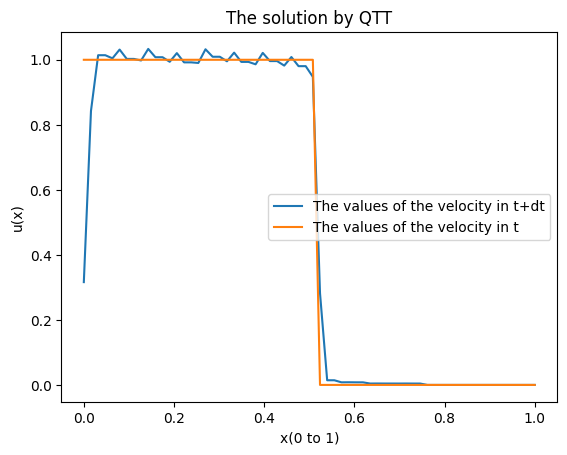

In [26]:
x = np.linspace(0, 1, 2**c)
plt.plot(x, dt_u_TT_array, label="The values of the velocity in t+dt")
plt.plot(x, initial_u_TT_array,label="The values of the velocity in t")

plt.xlabel("x(0 to 1)")
plt.ylabel("u(x)")
plt.title("The solution by QTT")
plt.legend()

plt.show()